# Week 4 — LSTM Autoencoder for Anomaly Detection

- LSTM autoencoder trains on normal trade patterns and flags months where the model struggles to reconstruct the sequence with high reconstruction error implying the month looks unusual compared to what the model learned during training.

- 12-month sliding windows for the top 30 trading partners were used along with the features are log_exports, log_imports, trade_balance, and export_import_ratio.

- Model architecture is:

  - LSTM(32) encoder

  - RepeatVector

  - LSTM(32) decoder

  - Dense(4).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


ROOT = _repo_root()


In [2]:
df = pd.read_csv(ROOT / "data/final/master_trade_flow.csv", parse_dates=["date"])

df["log_exports"]        = np.log1p(df["exports_usd"])
df["log_imports"]        = np.log1p(df["imports_usd"])
df["trade_balance"]      = df["exports_usd"] - df["imports_usd"]
df["export_import_ratio"] = df["exports_usd"] / df["imports_usd"].replace(0, np.nan)

FEATURES = ["log_exports", "log_imports", "trade_balance", "export_import_ratio"]

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
print("\nNaN counts for our 4 features:")
print(df[FEATURES].isna().sum())

Shape: (19584, 22)
Date range: 2017-01-01 00:00:00 → 2024-12-01 00:00:00

NaN counts for our 4 features:
log_exports             7
log_imports             9
trade_balance          16
export_import_ratio    64
dtype: int64


In [3]:
df["total_trade"] = df["exports_usd"] + df["imports_usd"]

top30 = (
    df.groupby("country_exp")["total_trade"]
    .sum()
    .nlargest(30)
    .index
    .tolist()
)

df30 = df[df["country_exp"].isin(top30)].copy()

print(f"Top 30 countries selected")
print(f"Rows in df30: {len(df30)}")
print(f"Countries: {df30['country_exp'].nunique()}")
print(f"\nCountry list:\n{top30}")

Top 30 countries selected
Rows in df30: 2880
Countries: 30

Country list:
['Mexico', 'Canada', 'China', 'Japan', 'Germany', 'Korea, South', 'United Kingdom', 'Taiwan', 'India', 'Vietnam', 'France', 'Netherlands', 'Italy', 'Ireland', 'Switzerland', 'Brazil', 'Singapore', 'Malaysia', 'Thailand', 'Belgium', 'Australia', 'Spain', 'Hong Kong', 'Israel', 'Indonesia', 'Colombia', 'Chile', 'Saudi Arabia', 'United Arab Emirates', 'Turkey']


In [4]:
WINDOW = 12

sequences = []
meta = []

for country, grp in df30.groupby("country_exp"):
    grp = grp.sort_values("date").reset_index(drop=True)
    data = grp[FEATURES].values  # (96, 4)

    for i in range(len(data) - WINDOW + 1):
        window = data[i : i + WINDOW]           # (12, 4)
        if np.isnan(window).any():
            continue
        sequences.append(window)
        meta.append({
            "country": country,
            "start_date": grp["date"].iloc[i],
            "end_date":   grp["date"].iloc[i + WINDOW - 1],
        })

X_raw = np.array(sequences)   # (N, 12, 4)
meta_df = pd.DataFrame(meta)

print(f"Total sequences : {len(X_raw)}")
print(f"Sequence shape  : {X_raw.shape}")
print(f"Sequences per country:\n{meta_df['country'].value_counts().describe()}")

Total sequences : 2550
Sequence shape  : (2550, 12, 4)
Sequences per country:
count    30.0
mean     85.0
std       0.0
min      85.0
25%      85.0
50%      85.0
75%      85.0
max      85.0
Name: count, dtype: float64


In [5]:
from sklearn.preprocessing import StandardScaler

# Reshaping to 2D to fit scaler, then back to 3D
N, T, F = X_raw.shape                         # (2550, 12, 4)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.reshape(-1, F)).reshape(N, T, F)

print(f"X_scaled shape : {X_scaled.shape}")
print(f"Mean (should ≈ 0): {X_scaled.reshape(-1, F).mean(axis=0).round(4)}")
print(f"Std  (should ≈ 1): {X_scaled.reshape(-1, F).std(axis=0).round(4)}")

X_scaled shape : (2550, 12, 4)
Mean (should ≈ 0): [ 0. -0. -0. -0.]
Std  (should ≈ 1): [1. 1. 1. 1.]


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

tf.random.set_seed(42)

inp = Input(shape=(T, F))                              # (12, 4)
encoded = LSTM(32, activation="relu")(inp)             # encoder (32,)
repeated = RepeatVector(T)(encoded)                    # (12, 32)
decoded = LSTM(32, activation="relu", return_sequences=True)(repeated)
out = TimeDistributed(Dense(F))(decoded)               # (12, 4)

model = Model(inp, out)
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 12, 4)          │           132 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,188 (51.52 KB)

 Trainable params: 13,188 (51.52 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_scaled, X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4137 - val_loss: 0.2315
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0882 - val_loss: 0.0980
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0593 - val_loss: 0.0739
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0537 - val_loss: 0.0639
Epoch 5/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0188

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0511 - val_loss: 0.0592
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0495 - val_loss: 0.0570
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0484 - val_loss: 0.0545
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0477 - val_loss: 0.0555
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0465 - val_loss: 0.0542
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0463 - val_loss: 0.0532
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0453 - val_loss: 0.0525
Epoch 12/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0457 - val_loss: 0.0522
Epoch 13/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0451 - val_loss: 0.0500
Epoch 14/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0448 - val_loss: 0.0522
Epoch 15/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0445 - val_loss: 0.0504
Epoch 16/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0445 - val_loss: 0.0

### Threshold Approach 1 — Global 95th Percentile

Flags any sequence whose reconstruction error is in the top 5% across all 2,550 sequences. Problem arises with Hong Kong's trade structure being different from resulting in its domination of the flagged list (85 of 85 sequences flagged). Hence not a real anomaly but instead just a structural outlier. Thus, other threshold alternatives were required.

In [8]:
X_pred = model.predict(X_scaled, verbose=0)

# MSE per sequence with shape (2550,)
recon_errors = np.mean(np.square(X_scaled - X_pred), axis=(1, 2))

threshold = np.percentile(recon_errors, 95)

print(f"Reconstruction error — min  : {recon_errors.min():.4f}")
print(f"Reconstruction error — mean : {recon_errors.mean():.4f}")
print(f"Reconstruction error — 95th : {threshold:.4f}")
print(f"Reconstruction error — max  : {recon_errors.max():.4f}")
print(f"\nSequences flagged as anomalies (above 95th): {(recon_errors > threshold).sum()}")

Reconstruction error — min  : 0.0022
Reconstruction error — mean : 0.0412
Reconstruction error — 95th : 0.1248
Reconstruction error — max  : 1.2141

Sequences flagged as anomalies (above 95th): 128


In [9]:
meta_df["recon_error"] = recon_errors
meta_df["lstm_anomaly"] = recon_errors > threshold
meta_df["threshold"] = threshold

print(meta_df.head(10))
print(f"\nTotal anomalies : {meta_df['lstm_anomaly'].sum()}")
print(f"\nAnomalies per country:")
print(meta_df.groupby("country")["lstm_anomaly"].sum().sort_values(ascending=False).head(15))

     country start_date   end_date  recon_error  lstm_anomaly  threshold
0  Australia 2017-01-01 2017-12-01     0.020515         False   0.124804
1  Australia 2017-02-01 2018-01-01     0.017500         False   0.124804
2  Australia 2017-03-01 2018-02-01     0.018501         False   0.124804
3  Australia 2017-04-01 2018-03-01     0.020183         False   0.124804
4  Australia 2017-05-01 2018-04-01     0.020841         False   0.124804
5  Australia 2017-06-01 2018-05-01     0.021609         False   0.124804
6  Australia 2017-07-01 2018-06-01     0.022336         False   0.124804
7  Australia 2017-08-01 2018-07-01     0.024739         False   0.124804
8  Australia 2017-09-01 2018-08-01     0.021830         False   0.124804
9  Australia 2017-10-01 2018-09-01     0.018323         False   0.124804

Total anomalies : 128

Anomalies per country:
country
Hong Kong               85
United Arab Emirates    39
China                    4
Australia                0
Korea, South             0
United 

### Threshold Approach 2 — Per-Country 95th Percentile

Per-country threshold with each country using its own 95th percentile provided an alternative to fix the Hong Kong problem. This gave exactly 5 flags per country (5% of 85 sequences = 4.25, rounded up). But a wall of 5s across all 30 countries is not informative — it means every country gets the same number of flags regardless of how stable or volatile it actually is. A better approach needs to reflect real differences between countries.

In [10]:
meta_df["country_threshold"] = meta_df.groupby("country")["recon_error"].transform(
    lambda x: np.percentile(x, 95)
)
meta_df["lstm_anomaly"] = meta_df["recon_error"] > meta_df["country_threshold"]

print(f"Total anomalies (per-country threshold): {meta_df['lstm_anomaly'].sum()}")
print(f"\nAnomalies per country:")
print(meta_df.groupby("country")["lstm_anomaly"].sum().sort_values(ascending=False))

Total anomalies (per-country threshold): 150

Anomalies per country:
country
Australia               5
Belgium                 5
United Kingdom          5
United Arab Emirates    5
Turkey                  5
Thailand                5
Taiwan                  5
Switzerland             5
Spain                   5
Singapore               5
Saudi Arabia            5
Netherlands             5
Mexico                  5
Malaysia                5
Korea, South            5
Japan                   5
Italy                   5
Israel                  5
Ireland                 5
Indonesia               5
India                   5
Hong Kong               5
Germany                 5
France                  5
Colombia                5
China                   5
Chile                   5
Canada                  5
Brazil                  5
Vietnam                 5
Name: lstm_anomaly, dtype: int64


In [11]:
flagged = meta_df[meta_df["lstm_anomaly"] == True].copy()
flagged["year"] = flagged["end_date"].dt.year

print("Flagged sequences by year:")
print(flagged["year"].value_counts().sort_index())

print("\nTop 20 flagged windows (end_date = last month in sequence):")
print(flagged[["country","start_date","end_date","recon_error"]]
      .sort_values("recon_error", ascending=False)
      .head(20)
      .to_string(index=False))

Flagged sequences by year:
year
2019     4
2020    67
2021    16
2022    18
2023    18
2024    27
Name: count, dtype: int64

Top 20 flagged windows (end_date = last month in sequence):
             country start_date   end_date  recon_error
           Hong Kong 2024-01-01 2024-12-01     1.214068
           Hong Kong 2023-11-01 2024-10-01     1.125963
           Hong Kong 2023-09-01 2024-08-01     1.097026
           Hong Kong 2023-10-01 2024-09-01     1.093132
           Hong Kong 2023-12-01 2024-11-01     1.078988
United Arab Emirates 2019-06-01 2020-05-01     0.251767
United Arab Emirates 2019-07-01 2020-06-01     0.244400
United Arab Emirates 2018-09-01 2019-08-01     0.226212
United Arab Emirates 2019-08-01 2020-07-01     0.219247
United Arab Emirates 2019-09-01 2020-08-01     0.217037
               China 2021-12-01 2022-11-01     0.150655
               China 2018-12-01 2019-11-01     0.139917
               China 2018-11-01 2019-10-01     0.134336
               China 2022-01-01

### Comparison with Isolation Forest V2

Comparison for which months both models flag simultaneously valideated the LSTM results. High overlap means two fundamentally different model types agree — strong evidence of a real anomaly. Low overlap means each model is catching something different.

In [12]:
from pathlib import Path

try:
    ROOT
except NameError:
    def _repo_root() -> Path:
        cwd = Path.cwd().resolve()
        if (cwd / "data" / "final").is_dir():
            return cwd
        if (cwd.parent / "data" / "final").is_dir():
            return cwd.parent
        return cwd
    ROOT = _repo_root()

if_df = pd.read_csv(ROOT / "data/final/anomaly_top30_results.csv", parse_dates=["date"])
lstm_df = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv", parse_dates=["date"])

print("IF V2 (anomaly_top30_results.csv)")
print("  shape:", if_df.shape)
print("  is_anomaly count:", int(if_df["is_anomaly"].sum()))
print("  columns:", if_df.columns.tolist())
print("\nLSTM (lstm_anomaly_results.csv)")
print("  shape:", lstm_df.shape)
print("  lstm_anomaly count:", int(lstm_df["lstm_anomaly"].sum()))
print("  columns:", lstm_df.columns.tolist())
print("\nSample country_display (IF):", if_df["country_display"].unique()[:5].tolist())
print("Sample country_display (LSTM):", lstm_df["country_display"].unique()[:5].tolist())

IF V2 (anomaly_top30_results.csv)
  shape: (2850, 20)
  is_anomaly count: 143
  columns: ['country_imf', 'country_display', 'date', 'year', 'month', 'log_exports', 'log_imports', 'trade_balance', 'exports_mom_pct', 'imports_mom_pct', 'export_import_ratio', 'log_exports_z', 'log_imports_z', 'trade_balance_z', 'exports_mom_pct_z', 'imports_mom_pct_z', 'export_import_ratio_z', 'anomaly', 'anomaly_score', 'is_anomaly']

LSTM (lstm_anomaly_results.csv)
  shape: (2550, 8)
  lstm_anomaly count: 152
  columns: ['country_display', 'date', 'lstm_anomaly', 'recon_error', 'is_anomaly', 'anomaly_score', 'both_flagged', 'recon_z']

Sample country_display (IF): ['Australia', 'Belgium', 'Brazil', 'Canada', 'Chile']
Sample country_display (LSTM): ['Australia', 'Belgium', 'Brazil', 'Canada', 'Chile']


In [13]:
## IF vs LSTM overlap (fresh from CSV — no training / meta_df)
from pathlib import Path

try:
    ROOT
except NameError:
    def _repo_root() -> Path:
        cwd = Path.cwd().resolve()
        if (cwd / "data" / "final").is_dir():
            return cwd
        if (cwd.parent / "data" / "final").is_dir():
            return cwd.parent
        return cwd
    ROOT = _repo_root()

if_df = pd.read_csv(ROOT / "data/final/anomaly_top30_results.csv", parse_dates=["date"])
lstm_df = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv", parse_dates=["date"])

merged = pd.merge(
    lstm_df[["country_display", "date", "lstm_anomaly", "recon_error"]],
    if_df[["country_display", "date", "is_anomaly", "anomaly_score"]],
    on=["country_display", "date"],
    how="inner",
)

both_m = (merged["lstm_anomaly"] & merged["is_anomaly"]).sum()
lstm_only_m = (merged["lstm_anomaly"] & ~merged["is_anomaly"]).sum()
if_only_m = (~merged["lstm_anomaly"] & merged["is_anomaly"]).sum()
neither_m = (~merged["lstm_anomaly"] & ~merged["is_anomaly"]).sum()

print(f"Inner-join rows (country_display + date): {len(merged)}")
print("\nOverlap on inner-join grid:")
print(f"  Both flagged : {both_m}")
print(f"  LSTM only    : {lstm_only_m}")
print(f"  IF only      : {if_only_m}")
print(f"  Neither      : {neither_m}")
if merged["lstm_anomaly"].sum():
    print(f"\nOverlap rate (of LSTM True on grid): {both_m / merged['lstm_anomaly'].sum() * 100:.1f}%")
if merged["is_anomaly"].sum():
    print(f"Overlap rate (of IF True on grid)  : {both_m / merged['is_anomaly'].sum() * 100:.1f}%")

if_anom = if_df[if_df["is_anomaly"]]
lstm_anom = lstm_df[lstm_df["lstm_anomaly"]]
d_if = pd.to_datetime(if_anom["date"]).dt.strftime("%Y-%m-%d")
d_ls = pd.to_datetime(lstm_anom["date"]).dt.strftime("%Y-%m-%d")
if_set = set(if_anom["country_display"].astype(str) + "_" + d_if.astype(str))
lstm_set = set(lstm_anom["country_display"].astype(str) + "_" + d_ls.astype(str))

print("\nAnomaly pair keys (country_display + '_' + date):")
print(f"  |if_set|   : {len(if_set)}")
print(f"  |lstm_set|: {len(lstm_set)}")
print(f"  Both      : {len(if_set & lstm_set)}")
print(f"  IF only   : {len(if_set - lstm_set)}")
print(f"  LSTM only : {len(lstm_set - if_set)}")

Inner-join rows (country_display + date): 2550

Overlap on inner-join grid:
  Both flagged : 27
  LSTM only    : 125
  IF only      : 109
  Neither      : 2289

Overlap rate (of LSTM True on grid): 17.8%
Overlap rate (of IF True on grid)  : 19.9%

Anomaly pair keys (country_display + '_' + date):
  |if_set|   : 143
  |lstm_set|: 152
  Both      : 27
  IF only   : 116
  LSTM only : 125


In [14]:
# Preview saved LSTM + IF merge artifact (read-only — does not overwrite CSVs)
from pathlib import Path

try:
    ROOT
except NameError:
    def _repo_root() -> Path:
        cwd = Path.cwd().resolve()
        if (cwd / "data" / "final").is_dir():
            return cwd
        if (cwd.parent / "data" / "final").is_dir():
            return cwd.parent
        return cwd
    ROOT = _repo_root()

lstm_saved = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv", parse_dates=["date"])
print(f"lstm_anomaly_results.csv  shape: {lstm_saved.shape}")
print(lstm_saved.head(3).to_string(index=False))

lstm_anomaly_results.csv  shape: (2550, 8)
country_display       date  lstm_anomaly  recon_error  is_anomaly  anomaly_score  both_flagged   recon_z
      Australia 2017-12-01         False     0.020609       False       0.137495         False -0.215397
      Australia 2018-01-01         False     0.016165       False       0.145839         False -0.437479
      Australia 2018-02-01         False     0.019868       False       0.022028         False -0.252455


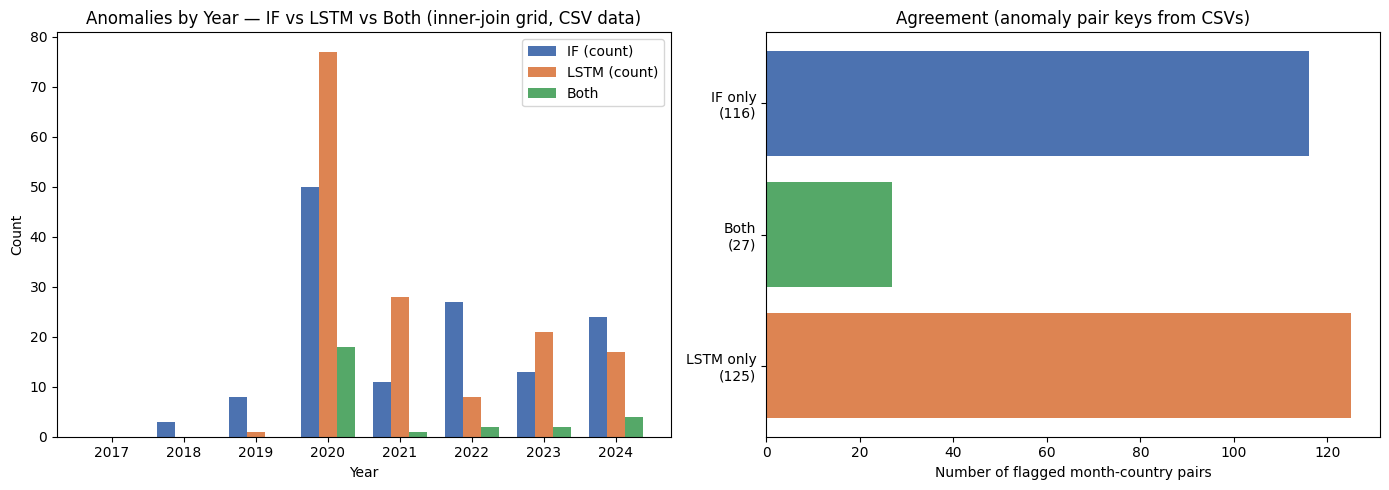

Plot saved.


In [15]:
from pathlib import Path

try:
    ROOT
except NameError:
    def _repo_root() -> Path:
        cwd = Path.cwd().resolve()
        if (cwd / "data" / "final").is_dir():
            return cwd
        if (cwd.parent / "data" / "final").is_dir():
            return cwd.parent
        return cwd
    ROOT = _repo_root()

if_df = pd.read_csv(ROOT / "data/final/anomaly_top30_results.csv", parse_dates=["date"])
lstm_df = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv", parse_dates=["date"])

merged = pd.merge(
    lstm_df[["country_display", "date", "lstm_anomaly", "recon_error"]],
    if_df[["country_display", "date", "is_anomaly", "anomaly_score"]],
    on=["country_display", "date"],
    how="inner",
)
merged["both_flagged"] = merged["lstm_anomaly"] & merged["is_anomaly"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly = merged.copy()
yearly["year"] = pd.to_datetime(yearly["date"]).dt.year

year_counts = yearly.groupby("year").agg(
    LSTM=("lstm_anomaly", "sum"),
    IF=("is_anomaly", "sum"),
    Both=("both_flagged", "sum")
).reset_index()

x = year_counts["year"]
w = 0.25
axes[0].bar(x - w, year_counts["IF"],   width=w, label="IF (count)",   color="#4C72B0")
axes[0].bar(x,     year_counts["LSTM"], width=w, label="LSTM (count)", color="#DD8452")
axes[0].bar(x + w, year_counts["Both"], width=w, label="Both",      color="#55A868")
axes[0].set_title("Anomalies by Year — IF vs LSTM vs Both (inner-join grid, CSV data)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].legend()

if_anom = if_df[if_df["is_anomaly"]]
lstm_anom = lstm_df[lstm_df["lstm_anomaly"]]
d_if = pd.to_datetime(if_anom["date"]).dt.strftime("%Y-%m-%d")
d_ls = pd.to_datetime(lstm_anom["date"]).dt.strftime("%Y-%m-%d")
if_set = set(if_anom["country_display"].astype(str) + "_" + d_if.astype(str))
lstm_set = set(lstm_anom["country_display"].astype(str) + "_" + d_ls.astype(str))

if_only = len(if_set - lstm_set)
lstm_only = len(lstm_set - if_set)
both = len(if_set & lstm_set)

labels = [f"LSTM only\n({lstm_only})", f"Both\n({both})", f"IF only\n({if_only})"]
values = [lstm_only, both, if_only]
colors = ["#DD8452", "#55A868", "#4C72B0"]
axes[1].barh(labels, values, color=colors)
axes[1].set_title("Agreement (anomaly pair keys from CSVs)")
axes[1].set_xlabel("Number of flagged month-country pairs")

plt.tight_layout()
plt.savefig(ROOT / "data/final/lstm_if_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [16]:
from pathlib import Path

try:
    ROOT
except NameError:
    def _repo_root() -> Path:
        cwd = Path.cwd().resolve()
        if (cwd / "data" / "final").is_dir():
            return cwd
        if (cwd.parent / "data" / "final").is_dir():
            return cwd.parent
        return cwd
    ROOT = _repo_root()

if_df = pd.read_csv(ROOT / "data/final/anomaly_top30_results.csv", parse_dates=["date"])
lstm_df = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv", parse_dates=["date"])

if_anom = if_df[if_df["is_anomaly"]]
lstm_anom = lstm_df[lstm_df["lstm_anomaly"]]
d_if = pd.to_datetime(if_anom["date"]).dt.strftime("%Y-%m-%d")
d_ls = pd.to_datetime(lstm_anom["date"]).dt.strftime("%Y-%m-%d")
if_set = set(if_anom["country_display"].astype(str) + "_" + d_if.astype(str))
lstm_set = set(lstm_anom["country_display"].astype(str) + "_" + d_ls.astype(str))
both_n = len(if_set & lstm_set)

print("  LSTM AUTOENCODER — SUMMARY (CSV counts; run training cells for model details)")
try:
    print(f"  Features        : {FEATURES}")
    print(f"  Window size     : {WINDOW} months")
    print(f"  Total sequences : {len(X_raw)}")
except NameError:
    print("  Features / window / sequences: (not in memory — run earlier cells if needed)")

print(f"  LSTM anomalies (file): {int(lstm_df['lstm_anomaly'].sum())}")
print(f"  IF V2 anomalies (file): {int(if_df['is_anomaly'].sum())}")
print(f"  Overlap (pair-key both): {both_n}")
print(f"  Results file    : data/final/lstm_anomaly_results.csv")

  LSTM AUTOENCODER — SUMMARY (CSV counts; run training cells for model details)
  Features        : ['log_exports', 'log_imports', 'trade_balance', 'export_import_ratio']
  Window size     : 12 months
  Total sequences : 2550
  LSTM anomalies (file): 152
  IF V2 anomalies (file): 143
  Overlap (pair-key both): 27
  Results file    : data/final/lstm_anomaly_results.csv


In [17]:
# IF vs LSTM stats from saved files (read-only; names should already match in CSVs)
from pathlib import Path

try:
    ROOT
except NameError:
    def _repo_root() -> Path:
        cwd = Path.cwd().resolve()
        if (cwd / "data" / "final").is_dir():
            return cwd
        if (cwd.parent / "data" / "final").is_dir():
            return cwd.parent
        return cwd
    ROOT = _repo_root()

if_df = pd.read_csv(ROOT / "data/final/anomaly_top30_results.csv", parse_dates=["date"])
lstm_df = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv", parse_dates=["date"])

merged = pd.merge(
    lstm_df[["country_display", "date", "lstm_anomaly", "recon_error"]],
    if_df[["country_display", "date", "is_anomaly", "anomaly_score"]],
    on=["country_display", "date"],
    how="inner",
)
merged["both_flagged"] = merged["lstm_anomaly"] & merged["is_anomaly"]

both = merged["both_flagged"].sum()
lstm_only = (merged["lstm_anomaly"] & ~merged["is_anomaly"]).sum()
if_only = (~merged["lstm_anomaly"] & merged["is_anomaly"]).sum()

print(f"Inner-join rows : {len(merged)}")
print(f"Countries       : {merged['country_display'].nunique()}")
print(f"Both flagged    : {both}")
print(f"LSTM only       : {lstm_only}")
print(f"IF only         : {if_only}")

if_anom = if_df[if_df["is_anomaly"]]
lstm_anom = lstm_df[lstm_df["lstm_anomaly"]]
d_if = pd.to_datetime(if_anom["date"]).dt.strftime("%Y-%m-%d")
d_ls = pd.to_datetime(lstm_anom["date"]).dt.strftime("%Y-%m-%d")
if_set = set(if_anom["country_display"].astype(str) + "_" + d_if.astype(str))
lstm_set = set(lstm_anom["country_display"].astype(str) + "_" + d_ls.astype(str))
print(f"\nPair-key overlap: both={len(if_set & lstm_set)}, IF-only={len(if_set - lstm_set)}, LSTM-only={len(lstm_set - if_set)}")

Inner-join rows : 2550
Countries       : 30
Both flagged    : 27
LSTM only       : 125
IF only         : 109

Pair-key overlap: both=27, IF-only=116, LSTM-only=125


### Threshold Approach 3 (Final) — Per-Country Z-Score

Getting z-score for each country's reconstruction error against its own mean and standard deviation, then flagging sequences where z > 2.0. Statistical groundING is based on countries with more volatile trade patterns getting more flags, stable countries get fewer.


In [18]:
lstm = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv")

lstm["recon_z"] = lstm.groupby("country_display")["recon_error"].transform(
    lambda x: (x - x.mean()) / x.std()
)

lstm["lstm_anomaly"] = lstm["recon_z"] > 2.0

print("Anomalies per country:")
print(lstm[lstm["lstm_anomaly"]].groupby("country_display").size().sort_values(ascending=False))
print("\nTotal:", lstm["lstm_anomaly"].sum())
print("Countries with 0 anomalies:", 30 - lstm[lstm["lstm_anomaly"]]["country_display"].nunique())

Anomalies per country:
country_display
Mexico                  10
Japan                    9
France                   9
India                    9
United Kingdom           7
United Arab Emirates     7
Vietnam                  7
Colombia                 7
Brazil                   7
Turkey                   6
Taiwan                   6
South Korea              6
Belgium                  5
Saudi Arabia             5
Germany                  5
Netherlands              5
China                    5
Australia                5
Italy                    4
Switzerland              4
Malaysia                 3
Chile                    3
Israel                   3
Singapore                3
Indonesia                3
Canada                   3
Ireland                  2
Spain                    2
Thailand                 1
Hong Kong                1
dtype: int64

Total: 152
Countries with 0 anomalies: 0


In [19]:
lstm.to_csv(ROOT / "data/final/lstm_anomaly_results.csv", index=False)
print("Columns:", lstm.columns.tolist())
print("lstm_anomaly total:", lstm["lstm_anomaly"].sum())

Columns: ['country_display', 'date', 'lstm_anomaly', 'recon_error', 'is_anomaly', 'anomaly_score', 'both_flagged', 'recon_z']
lstm_anomaly total: 152


The z-score approach gives natural variation across countries — France (9), Mexico (9) India (9) — reflecting genuine differences in trade volatility rather than an artificial uniform count. Stable countries like Spain and Thailand get fewer flags. The total of 152 anomalies across 30 countries are identified.

In [21]:
import pandas as pd
from pathlib import Path


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


FINAL = _repo_root() / "data" / "final"

if2 = pd.read_csv(FINAL / "anomaly_top30_results.csv", parse_dates=["date"])
lstm = pd.read_csv(FINAL / "lstm_anomaly_results.csv", parse_dates=["date"])

if_total = int(if2["is_anomaly"].sum())
lstm_total = int(lstm["lstm_anomaly"].sum())

if_anom = if2[if2["is_anomaly"] == True]
lstm_anom = lstm[lstm["lstm_anomaly"] == True]

d_if = pd.to_datetime(if_anom["date"]).dt.strftime("%Y-%m-%d")
d_ls = pd.to_datetime(lstm_anom["date"]).dt.strftime("%Y-%m-%d")
if_set = set(if_anom["country_display"].astype(str) + "_" + d_if.astype(str))
lstm_set = set(lstm_anom["country_display"].astype(str) + "_" + d_ls.astype(str))

print(f"IF: {if_total}")
print(f"LSTM: {lstm_total}")
print(f"IF only: {len(if_set - lstm_set)}")
print(f"LSTM only: {len(lstm_set - if_set)}")
print(f"Both: {len(if_set & lstm_set)}")

IF: 143
LSTM: 152
IF only: 116
LSTM only: 125
Both: 27
